Original samples: 2800
Augmented samples: 8400
X_train shape: (1920, 13, 1)
y_train shape: (1920, 6)
X_test shape: (480, 13, 1)
y_test shape: (480, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 1, 32)      │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 416)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        13,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,862 (54.15 KB)

 Trainable params: 13,862 (54.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3688 - loss: 2.4817 - val_accuracy: 0.4938 - val_loss: 1.1891
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5802 - loss: 1.0178 - val_accuracy: 0.6792 - val_loss: 0.8050
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7010 - loss: 0.7206 - val_accuracy: 0.7646 - val_loss: 0.6411
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7729 - loss: 0.5881 - val_accuracy: 0.8062 - val_loss: 0.5533
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8109 - loss: 0.5211 - val_accuracy: 0.8167 - val_loss: 0.4742
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8245 - loss: 0.4790 - val_accuracy: 0.8333 - val_loss: 0.4940
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8443 - loss: 0.4349 - val_accuracy: 0.8646 - val_loss: 0.4086
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8661 - loss: 0.3895 - val_accuracy: 0.8583 - val_loss

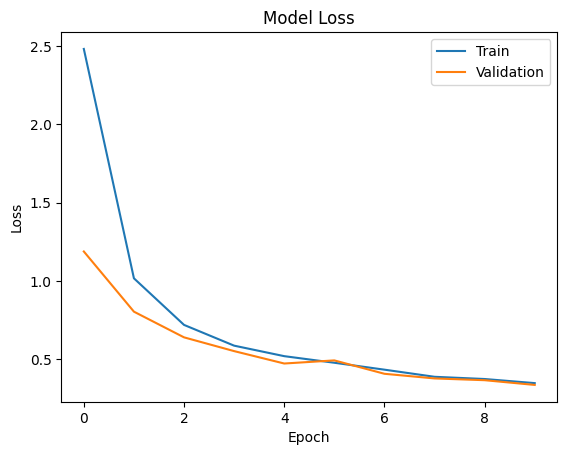

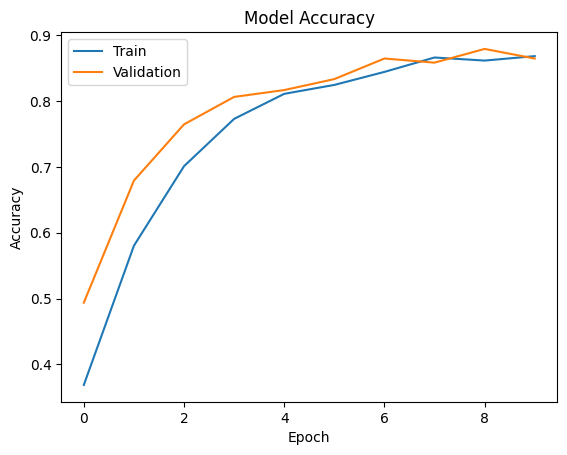

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


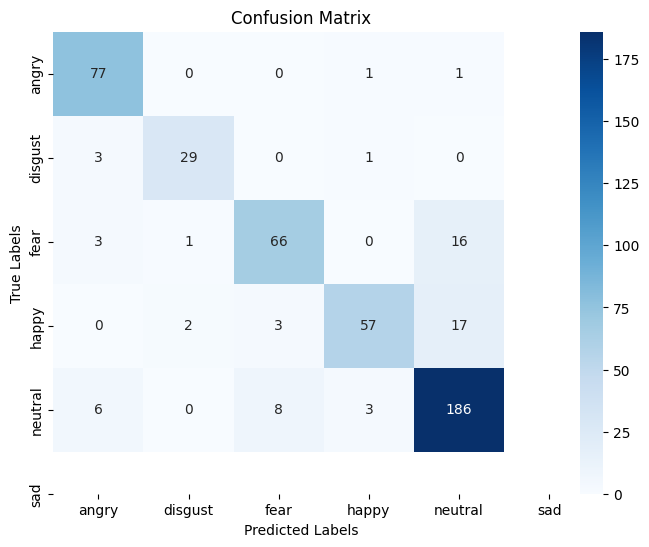

              precision    recall  f1-score   support

       angry       0.87      0.97      0.92        79
     disgust       0.00      0.00      0.00         0
        fear       0.91      0.88      0.89        33
       happy       0.86      0.77      0.81        86
     neutral       0.92      0.72      0.81        79
         sad       0.85      0.92      0.88       203

    accuracy                           0.86       480
   macro avg       0.73      0.71      0.72       480
weighted avg       0.87      0.86      0.86       480

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8839 - loss: 0.3350 - val_accuracy: 0.8472 - val_loss: 0.3636
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8765 - loss: 0.3513 - val_accuracy: 0.8750 - val_loss: 0.3253
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8824 - loss: 0.3192 - val_accuracy: 0.8750 - val_loss: 0.3228
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8936 - loss: 0.

In [ ]:

# EMOTION DETECTION THROUGH SPEECH SIGNAL USING CNN



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from IPython.display import Audio
import librosa
import librosa.display

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)


# DATASET PATH 

data_dir = r"C:\Users\devan\OneDrive\Desktop\gptmaking\project2\emotionproj\TESS Toronto emotional speech set data"   # <-- change this


#  DATA COLLECTION - Load MFCC features 

features = []
labels = []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        emotion_label = folder.split('_')[-1]  # Extract the emotion label from folder name

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if file_path.endswith('.wav'):
                # Load the audio file and extract features
                audio, sr = librosa.load(file_path, duration=3)  # Adjust duration as needed
                mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
                mfcc_mean = np.mean(mfcc, axis=1)
                features.append(mfcc_mean)
                labels.append(emotion_label)


features = np.array(features)
labels = np.array(labels)


label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)


# FEATURE EXTRACTION 
from tensorflow.keras.preprocessing.sequence import pad_sequences

augmented_features = []
augmented_labels = []

for feature, label in zip(features, labels):
    augmented_features.append(feature)
    augmented_labels.append(label)

    # Apply noise addition
    noise = np.random.randn(len(feature))
    augmented_features.append(feature + 0.005 * noise)  
    augmented_labels.append(label)

    # Apply time stretching
    augmented_features.append(librosa.effects.time_stretch(feature, rate=1.2))  
    augmented_labels.append(label)

# Apply pitch shifting
def pitch(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sampling_rate, pitch_factor)

# Convert to NumPy arrays
max_length = 1000  
augmented_features = pad_sequences(augmented_features, maxlen=max_length, dtype='float32', padding='post', truncating='post')

# Convert  to NumPy arrays
augmented_features = np.array(augmented_features)
augmented_labels = np.array(augmented_labels)


print('Original samples:', len(features))
print('Augmented samples:', len(augmented_features))


#  PRE-PROCESSING

preprocessed_data = []
file_list = os.listdir(data_dir)

for filename in file_list:
    file_path = os.path.join(data_dir, filename)

    # Skip non-audio 
    if not filename.endswith('.wav'):
        continue

    
    waveform, sr = librosa.load(file_path, sr=None, dtype=np.float32)

  
    if sr != 22050:
        waveform = librosa.resample(waveform, sr, 22050)
        sr = 22050


#  SPECTROGRAM VISUALISATION




#  ENCODE LABELS & TRAIN/TEST SPLIT 
label_mapping = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5}

# Encode the emotion labels
encoded_labels = np.array([label_mapping.get(label, -1) for label in labels])

# Filter out any samples with unknown emotion labels
valid_indices = np.where(encoded_labels != 1)[0]  
features = features[valid_indices]
encoded_labels = encoded_labels[valid_indices]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, encoded_labels, test_size=0.2, random_state=42)

# Reshape the input features
X_train = X_train.reshape((*X_train.shape, 1))
X_test = X_test.reshape((*X_test.shape, 1))

# Convert the emotion labels to categorical format
num_classes = len(label_mapping)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

#  PRINT SHAPES 
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


#  BUILD CNN MODEL 

model = Sequential()

# Add the first convolutional layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(13, 1, 1), padding='same'))


model.add(Flatten())


model.add(Dense(32, activation='relu'))


model.add(Dense(6, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


#  TRAIN & EVALUATE
history = model.fit(X_train, y_train, batch_size=64, epochs=10, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print("Test loss:", loss)
print("Test accuracy:", accuracy)

# PRINT ACCURACY ON TEST DATA 
print("Accuracy of our model on test data : ", model.evaluate(X_test, y_test)[1] * 100, "%")


#  PLOT TRAINING & VALIDATION LOSS 

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()


#  PLOT TRAINING & VALIDATION ACCURACY 

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


#  CONFUSION MATRIX 
# Get the predicted labels for the test set
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)  # Convert one-hot encoded predictions to labels

# Convert the true labels from one-hot encoding to labels
y_true_labels = np.argmax(y_test, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']
report = classification_report(y_true_labels, y_pred_labels, target_names=class_names, labels=range(len(class_names)))

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


#  CLASSIFICATION REPORT 
print(report)


# RETRAIN WITH VALIDATION SPLIT
history = model.fit(X_train, y_train, validation_split=0.3, epochs=10, batch_size=64)

#  TRAIN DATA ACCURACY 
print("Accuracy of our model on train data : ", model.evaluate(X_train, y_train)[1] * 100, "%")